# Analiza zawodników w Fifie 22

### Cel projektu
Celem projektu jest dogłębna analiza atrybutów zawodników w grze FIFA 22 oraz zbudowanie modeli regresyjnych uczenia maszynowego, które na podstawie cech fizycznych i technicznych (takich jak przyspieszenie, wykończenie akcji, drybling czy wiek) będą precyzyjnie prognozować wartość rynkową piłkarzy.

### Opis zbioru danych
#### Zbiór danych
 Zbiór danych wykorzystany w projekcie został pobrany ze strony Kaggel(https://www.kaggle.com/datasets/stefanoleone992/fifa-22-complete-player-dataset)


#### Określenie zmiennej docelowej
 Zmienną docelową jest **value_euro** oznaczającą aktualną (na sezon 2022/2023) wartość runkową piłkarzy


#### Wymiary zbioru
Zbiór danych po wstepnej obróbce ma 17041 zawodników oraz 58 zmiennych 


#### Typy danych
 Po obróbce typów danych w zbiorze wystepują typy:
    numeryczne (int64 oraz float64) opisujące zmienne ilościowe takie jak wartość zawodnika, wiek czy ocena ogólna piłkarza.
    Tekstowe (object) przeznaczone dla zmiennych jakosciowych(kategorycznych), takich jak imie, nazwisko, pozycja na boisku czy preferowana noga 


#### Objaśnienie poszczególnych zmiennych:
| Nazwa zmiennej | Typ danych | Opis i rola w projekcie |
| :--- | :--- | :--- |
| **`short_name`** | `object` | Imię i nazwisko (lub pseudonim) piłkarza. |
| **`value_eur`** | `float64` | Aktualna wartość rynkowa piłkarza wyrażona w euro (**Zmienna docelowa**). |
| **`player_positions`** | `object` | Pozycje, na których zawodnik może występować (np. ST, RW, CAM) |
| **`overall`** | `int64` | Ogólna ocena zawodnika w skali 1-99, określająca jego obecny poziom sportowy. |
| **`potential`** | `int64` | Maksymalna ocena ogólna, jaką zawodnik może osiągnąć w przyszłości (kluczowa dla młodych talentów). |
| **`age`** | `int64` | Wiek zawodnika wyrażony w latach. |
| **`pace`** | `float64` | Główny atrybut określający tempo, szybkość oraz przyspieszenie zawodnika. |
| **`shooting`** | `float64` | Główny atrybut określający skuteczność wykończenia akcji i siłę strzału. |
| **`passing`** | `float64` | Główny atrybut określający precyzję podań krótko- i długodystansowych. |
| **`dribbling`** | `float64` | Główny atrybut określający kontrolę nad piłką, zwinność oraz balans. |
| **`defending`** | `float64` | Główny atrybut określający statystyki obronne, wślizgi i intuicję w defensywie. |
| **`physic`** | `float64` | Główny atrybut określający siłę fizyczną, wydolność oraz agresję zawodnika. |


### Przykładowe rekordy
Poniższa tabela prezentuje wycinek 5 pierwszych zawodników z bazy danych, odwzorowując strukturę zmiennych opisaną w powyższej sekcji:

| short_name | value_eur | player_positions | overall | potential | age | pace | shooting | passing | dribbling | defending | physic |
| :--- | :---: | :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| L. Messi | 78 000 000 | RW, ST, CF | 93 | 93 | 34 | 85 | 92 | 91 | 95 | 34 | 65 |
| R. Lewandowski | 119 500 000 | ST | 92 | 92 | 32 | 78 | 92 | 79 | 86 | 44 | 82 |
| Cristiano Ronaldo | 45 000 000 | ST, LW | 91 | 91 | 36 | 87 | 94 | 80 | 88 | 34 | 75 |
| Neymar Jr | 129 000 000 | LW, CAM | 91 | 91 | 29 | 91 | 83 | 86 | 94 | 32 | 63 |
| K. De Bruyne | 125 500 000 | CM, CAM | 91 | 91 | 30 | 76 | 86 | 93 | 88 | 64 | 78 |

In [209]:
import pandas as pd
import numpy as np

df = pd.read_csv('FIFA 22.csv', sep=',')

glowne_liczbowe = ['overall', 'potential', 'age', 'value_eur', 'wage_eur', 'release_clause_eur']

atrybuty_skills = [
    col for col in df.columns 
    if col not in ['sofifa_id', 'player_url', 'short_name', 'long_name', 'player_positions', 
                   'dob', 'club_name', 'league_name', 'club_position', 'club_loaned_from', 
                   'club_joined', 'nationality_name', 'preferred_foot', 'work_rate', 
                   'body_type', 'real_face', 'player_tags', 'player_traits']
    and not col.endswith('_url')
]

wszystkie_do_naprawy = list(set(glowne_liczbowe + atrybuty_skills))

for kolumna in wszystkie_do_naprawy:
    if kolumna in df.columns:
        if df[kolumna].dtype == 'object':
            df[kolumna] = df[kolumna].astype(str).str.split('+').str[0].str.split('-').str[0]
        df[kolumna] = pd.to_numeric(df[kolumna], errors='coerce')

wybrane_kolumny = ['overall', 'potential', 'value_eur', 'pace', 'shooting', 'passing', 'dribbling']
print(df[wybrane_kolumny].dtypes)

print(df[wybrane_kolumny].isnull().sum())

print("\nRozmiar całej bazy danych:", df.shape)

overall        int64
potential      int64
value_eur    float64
pace         float64
shooting     float64
passing      float64
dribbling    float64
dtype: object
overall         0
potential       0
value_eur      74
pace         2132
shooting     2132
passing      2132
dribbling    2132
dtype: int64

Rozmiar całej bazy danych: (19239, 110)


C:\Users\Użytkownik\AppData\Local\Temp\ipykernel_10020\3294613426.py:4: DtypeWarning: Columns (0: nation_position, 1: nation_logo_url) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('FIFA 22.csv', sep=',')


In [210]:
df_field = df[
    (df['pace'].notna()) & 
    (df['pace'] > 0) & 
    (df['value_eur'].notna()) & 
    (df['value_eur'] > 0)
].copy()
print(f"Rozmiar bazy po czyszczeniu (tylko aktywni zawodnicy z pola): {df_field.shape[0]} wierszy")
print(f"Usunięto łącznie {df.shape[0] - df_field.shape[0]} rekordów.")

print("\n BRAKI DANYCH W NOWYM ZBIORZE ")
wybrane_kolumny_pole = ['overall', 'potential', 'value_eur', 'pace', 'shooting', 'passing', 'dribbling']
print(df_field[wybrane_kolumny_pole].isnull().sum())

Rozmiar bazy po czyszczeniu (tylko aktywni zawodnicy z pola): 17041 wierszy
Usunięto łącznie 2198 rekordów.

 BRAKI DANYCH W NOWYM ZBIORZE 
overall      0
potential    0
value_eur    0
pace         0
shooting     0
passing      0
dribbling    0
dtype: int64


In [211]:
kolumny_do_wywalenia = [
    'sofifa_id', 'player_url', 'player_face_url', 'club_logo_url', 
    'club_flag_url', 'nation_logo_url', 'nation_flag_url', 'real_face', 'long_name',
    'dob', 'club_joined', 'club_loaned_from', 'nation_position', 'nation_jersey_number',
    'club_team_id', 'nationality_id', 'nation_team_id',
    'player_tags', 'player_traits',
    'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 
    'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_speed',
    'ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw', 'lam', 'cam', 'ram', 
    'lm', 'lcm', 'cm', 'rcm', 'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 
    'lb', 'lcb', 'cb', 'rcb', 'rb', 'gk'
]

istniejace_do_usuniecia = [col for col in kolumny_do_wywalenia if col in df_field.columns]
df_field = df_field.drop(columns=istniejace_do_usuniecia)
print(f"Nowy rozmiar bazy danych: {df_field.shape[0]} wierszy i {df_field.shape[1]} kolumn.")


Nowy rozmiar bazy danych: 17041 wierszy i 58 kolumn.


In [212]:
df_eda = df_field.copy()

df_eda['value_eur'] = df_eda['value_eur'] / 1_000_000

print("PODSTAWOWE STATYSTYKI OPISOWE DLA ZMIENNYCH NUMERYCZNYCH (WARTOŚĆ W MLN EUR)")
zmienne_numeryczne = ['value_eur', 'overall', 'potential', 'age']
statystyki = df_eda[zmienne_numeryczne].describe().round(2)
print(statystyki)


PODSTAWOWE STATYSTYKI OPISOWE DLA ZMIENNYCH NUMERYCZNYCH (WARTOŚĆ W MLN EUR)
       value_eur   overall  potential       age
count   17041.00  17041.00   17041.00  17041.00
mean        2.97     65.93      71.24     25.07
std         7.72      6.77       6.05      4.61
min         0.02     47.00      49.00     16.00
25%         0.52     62.00      67.00     21.00
50%         1.00     66.00      71.00     25.00
75%         2.10     70.00      75.00     28.00
max       194.00     93.00      95.00     39.00


Na podstawie obliczonych wskaźników statystycznych i rozkładów najważniejszych zmiennych numerycznych sformułowano następujące wnioski:

* **Wartość rynkowa (`value_eur` w mln €):** Średnia wycena zawodnika z pola wynosi 2.97 mln euro, podczas gdy mediana kształtuje się na poziomie równym 1.00 mln euro. Fakt, że średnia arytmetyczna jest niemal trzykrotnie wyższa od mediany, przy bardzo wysokim odchyleniu standardowym (std = 7.72 mln euro), dowodzi występowania silnej asymetrię prawostronnej. Jest to uwarunkowane tym, że duża liczba piłkarzy gra w słabych ligach i jest relatywnie tania, ponieważ 75% zawodnkiów jest wartych 2.10 mln euro lub mniej. Średnią zawyżają wybitni zawodnicy grający w najlepszych ligach w europie, którzy potrafią być warci nawet ponad 120 mln euro 

* **Poziom sportowy (`overall`):** Rozkład oceny umiejętności zawodników jest bardzo zblizony do rozkładu normalnego, ze średnią na poziomie 65.93 pkt oraz z medianą równą 66 pkt. Odchylenie standardowe wynoszące 6.77 pkt wskazuje na silne skupienie obserwacji wokół środka skali. Oznacza to że znaczna liczba piłkarzy ma overall w okolicach średniej, a graczy wybitnych w grze jest bardzo mało. Uwarunkowane jest to tym, że w grze jest kilkadziesiąt lig z czego tylko 3/4 to ligi wybitne, więc jest to zrozumiałe że trzon bazy danych opiera się na słabych piłkarzach.

* **Potencjał rozwoju (`potential`):** Średnia wartość potencjału piłkarza wynosi 71.24 pkt i jest ona wyższa od średniej wartości. Jest to zrozumiałe, ponieważ zawodnicy zwłaszcza ci młodsi wraz z upływem lat mogą się rozwinąć i zwiększyć swoje umiejętności.

* **Wiek zawodników (`age`):** Średni wiek w oczyszczonej bazie danych wynosi 25.07 lat (przy medianie wynoszącej 25 lat) z odchyleniem standardowym 4.61. Pokazuje to, że większość zawodników w grze jest w swoim optymalnym wieku do uprawiania sportu zawodowego. Przedział wiekowy wynosi 16-39 lat, więc na boiskach możemy zobaczyć nastolatków jak i już piłkarzy w końcowym etapie kariery.

In [213]:
print("ANALIZA GRUPOWA: PORÓWNANIE WYBRANYCH NARODOWOŚCI")
wybrane_nacje = ['Poland', 'England', 'France', 'Spain', 'Germany']

nacje_analiza = df_eda[df_eda['nationality_name'].isin(wybrane_nacje)].groupby('nationality_name')[['value_eur', 'overall']].mean()

print(nacje_analiza.round(2).sort_values(by='value_eur', ascending=False))

ANALIZA GRUPOWA: PORÓWNANIE WYBRANYCH NARODOWOŚCI
                  value_eur  overall
nationality_name                    
Spain                  5.54    69.71
France                 4.93    67.71
Germany                2.91    65.78
England                2.67    64.10
Poland                 1.54    63.20


### Porównanie narodowości pod względem wartości i overallu
Wskutek głębszej analizy zbioru danych pogrupowano piłkarzy ze względu na wybrane narodowości i obliczono ich średnią wartość rynkową oraz ogólną ocenę (overall). Wyniki jednoznacznie pokazują, że Hiszpanie mają najwyższą średnią wartość, wynoszącą 5.54 mln euro. Średni overall reprezentantów Hiszpanii również uplasował się na pierwszym miejscu z wynikiem 69.71 pkt. O równo dwa punkty mniej wynosi średnia ocena Francuzów (67.71 pkt), natomiast średnia wartość francuskiego piłkarza jest równa 4.93 mln euro. 

Ciekawym przypadkiem są zawodnicy angielscy, którzy pomimo posiadania najlepszej ligi krajowej na świecie, okazują się w tym zestawieniu dosyć tani. Jest to uwarunkowane tym, że w grze Anglia ma odwzorowane ligi aż do 4 poziomu rozgrywkowego, podczas gdy wyżej wymieniona Hiszpania posiada jedynie 2 poziomy. Przekłada się to bezpośrednio na większą liczbę angielskich piłkarzy grających w słabszych klubach, co w efekcie skutkuje drastycznie niższą średnią wartością zawodników oraz ich overallem. Polacy w zestawieniu prezentują się najgorzej, co wynika z bardzo słabej pozycji rodzimej ligi w grze oraz niewielkiej liczby wybitnych piłkarzy występujących w czołowych ligach zagranicznych.

In [214]:
df_field['main_position'] = df_field['player_positions'].astype(str).apply(lambda x: x.split(',')[0].strip())

boczni_obroncy = ['LB', 'RB', 'LWB', 'RWB']
srodkowi_obroncy = ['CB']

def przypisz_grupe_obrony(pozycja):
    if pozycja in boczni_obroncy:
        return 'Boczni Obrońcy'
    elif pozycja in srodkowi_obroncy:
        return 'Środkowi Obrońcy'
    return None

df_field['profile_group'] = df_field['main_position'].apply(przypisz_grupe_obrony)

glowne_atrybuty = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'value_eur']
profil_analiza = df_field[df_field['profile_group'].notna()].groupby('profile_group')[glowne_atrybuty].mean()

profil_analiza['value_eur'] = profil_analiza['value_eur'] / 1_000_000
profil_analiza = profil_analiza.rename(columns={'value_eur': 'value_eur_mln'})

print(profil_analiza.round(2).T) 

profile_group  Boczni Obrońcy  Środkowi Obrońcy
pace                    72.88             59.13
shooting                44.82             35.81
passing                 57.20             48.75
dribbling               62.58             51.30
defending               61.59             65.82
physic                  65.38             71.14
value_eur_mln            2.52              2.53


### Analiza statystyk środkowych oraz bocznych obrońców
Wskutek dogłębnej analizy statystyk bocznych oraz środkowych obrońców można zaobserwować, że stoperzy są zdecydowanie mniej wszechstronni niż boczni obrońcy. Centralni defensorzy charakteryzują się wyższą fizycznością oraz lepszymi umiejętnościami czysto defensywnymi, niemniej jednak w innych statystykach są dużo bardziej przeciętni. Boczni obrońcy wyróżniają się zdecydowanie większą szybkością (średnio o prawie 13 pkt), a na innych płaszczyznach niedefensywnych również przewyższają swoimi umiejętnościami kolegów ze środka formacji. Wyniki te są dość naturalne, ponieważ boczni obrońcy często mają nie tylko zadania defensywne, lecz także ofensywne, stąd też nie dziwią ich wyższe średnie wartości podań czy dryblingu. Środkowi obrońcy są natomiast rozliczani przede wszystkim ze swoich umiejętności defensywnych.

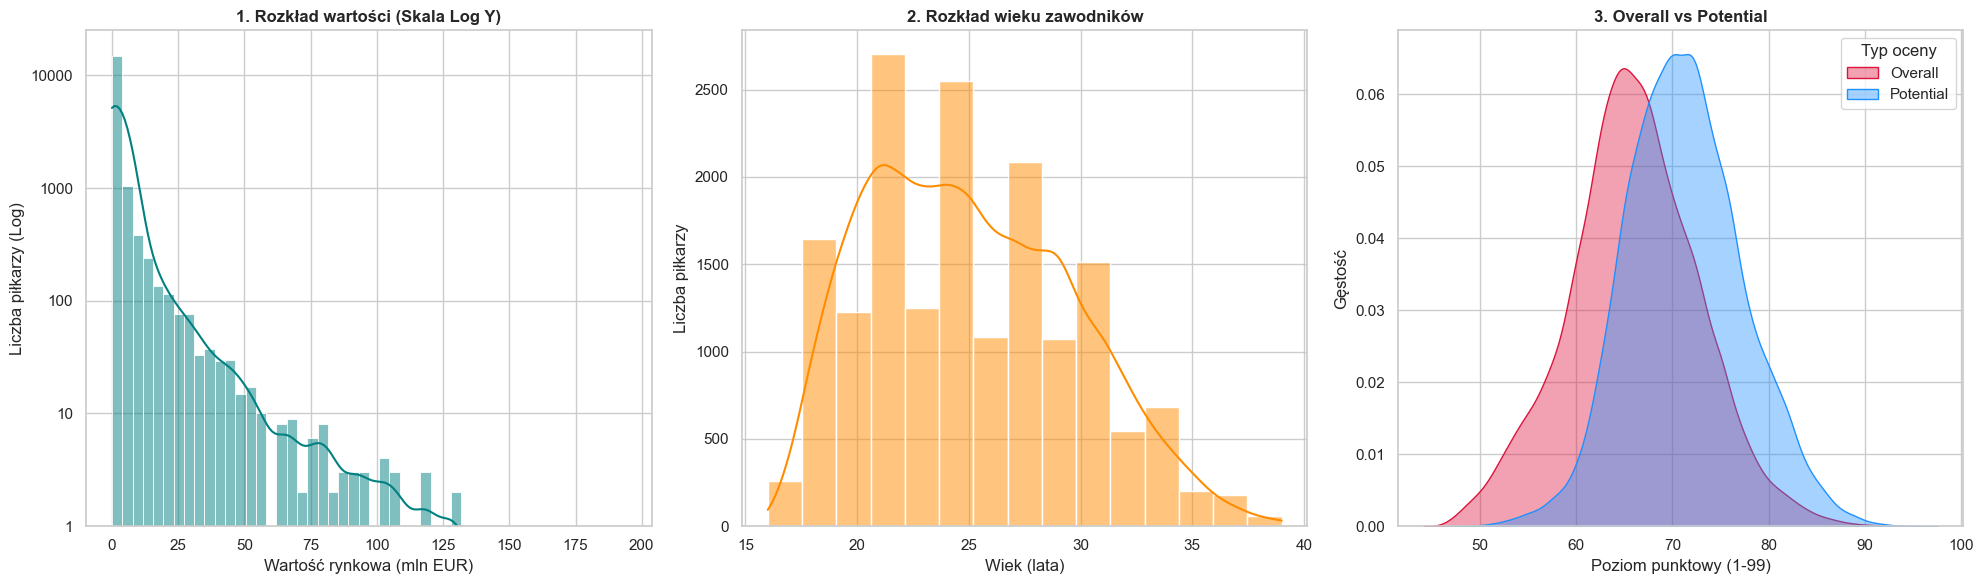

In [215]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(data=df_field, x=df_field['value_eur'] / 1_000_000, kde=True, 
             color='teal', ax=axes[0], bins=50, kde_kws={'bw_adjust': 4})

axes[0].set_yscale('log')
axes[0].set_ylim(1, 25000)
axes[0].set_yticks([1, 10, 100, 1000, 10000])
axes[0].get_yaxis().set_major_formatter(plt.ScalarFormatter())

axes[0].set_title('1. Rozkład wartości (Skala Log Y)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Wartość rynkowa (mln EUR)')
axes[0].set_ylabel('Liczba piłkarzy (Log)')

sns.histplot(data=df_field, x='age', kde=True, color='darkorange', ax=axes[1], bins=15)
axes[1].set_title('2. Rozkład wieku zawodników', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Wiek (lata)')
axes[1].set_ylabel('Liczba piłkarzy')

sns.kdeplot(data=df_field, x='overall', fill=True, color="crimson", label='Overall', alpha=0.4, ax=axes[2])
sns.kdeplot(data=df_field, x='potential', fill=True, color="dodgerblue", label='Potential', alpha=0.4, ax=axes[2])

axes[2].set_title('3. Overall vs Potential', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Poziom punktowy (1-99)')
axes[2].set_ylabel('Gęstość')
axes[2].legend(title='Typ oceny')

plt.tight_layout()
plt.show()

### Rozkład wartości rynkowej zawodników (Skala logarytmiczna Y)
Rozkład wartości rynkowej charakteryzuje się ogromną prawostronną skośnością. Zastosowanie skali logarytmicznej na osi Y było konieczne, ponieważ ponad 90% zawodników w bazie to gracze o relatywnie niskiej wartości (poniżej 5–10 mln EUR), podczas gdy garstka gwiazd osiąga astronomiczne wyceny przekraczające 100 mln EUR. Wykres idealnie odzwierciedla realia ekonomiczne współczesnego futbolu, gdzie rynek jest zdominowany przez tzw. piłkarską "klasę średnią i niższą". Piłkarze z prawego końca osi X (powyżej 100 mln EUR) to anomalie rynkowe, co w pełni uzasadniało zastosowanie w dalszych krokach projektu techniki przycinania wartości.

### Rozkład wieku zawodników
Rozkład wieku przypomina rozkład zbliżony do normalnego, jednak z wyraźnym spłaszczeniem w centrum. Największa gęstość próbki przypada na przedział od 21 do 25 lat. Wyraźny, gwałtowny spadek liczby piłkarzy po 30. roku życia odzwierciedla naturalny proces kończenia karier na poziomie profesjonalnym, spadek wydolności oraz wygasanie kontraktów u starszych graczy.

### Porównanie rozkładów: Overall vs Potential
Oba rozkłady mają charakterystykę rozkładu normalnego, ale rozkład potencjału jest wyraźnie przesunięty w prawą stronę względem obecnych umiejętności. Średnia dla potencjału jest wyższa, a sam wykres jest nieco bardziej smukły. Jest to tzw. "margines rozwoju". Pokazuje on logiczną zależność w grach z serii FIFA: większość zawodników (szczególnie młodych) nie osiągnęła jeszcze pełni swoich możliwości. Stąd wynika przesunięcie rozkładu potencjału wzgledem overallu.

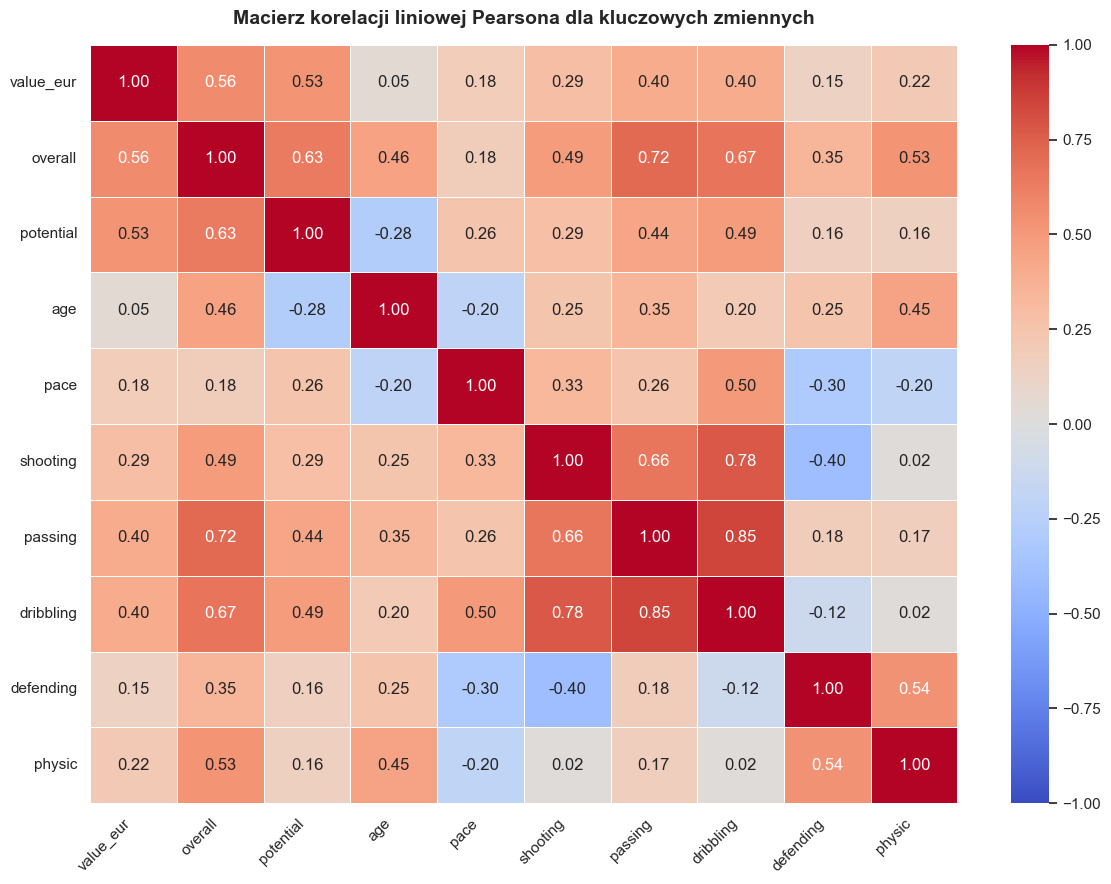

In [216]:
zmienne_korelacja = [
    'value_eur', 'overall', 'potential', 'age', 
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic'
]

macierz_kor = df_field[zmienne_korelacja].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(macierz_kor, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Macierz korelacji liniowej Pearsona dla kluczowych zmiennych', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Macierz korelacji kluczowych zmiennych
Z macierzy korelacji jasno wynika, że największy wpływ na wartość piłkarza ma overall oraz potencjał. Na wyższą wycenę zawodnika wpływają również umiejętności dryblingu i podań, które są jednocześnie bardzo silnie skorelowane ze sobą. Zaskakujące jest przy tym to, że drybling wykazuje mniejszą korelację z szybkością niż z podaniami, choć w rzeczywistości ciężko sobie wyobrazić piłkarza, który dobrze drybluje, a jest wolny. Na overall również najsilniej oddziałują drybling oraz podania.Silnie skorelowane ujemnie są ze sobą strzelanie i umiejętność gry w obronie. Jest to jednak dość naturalne, gdyż są to statystyki typowe odpowiednio dla napastników lub obrońców. Ciekawą anomalią jest natomiast korelacja wieku z wartością piłkarza. Z doświadczenia wiadomo, że wiek bardzo mocno wpływa na wycenę (bardzo starzy zawodnicy są wyceniani nisko), niemniej jednak z samej macierzy wynikałoby, że nie ma on znaczenia. Pokazuje to jednoznacznie, że korelacja ta ma charakter nieliniowy.

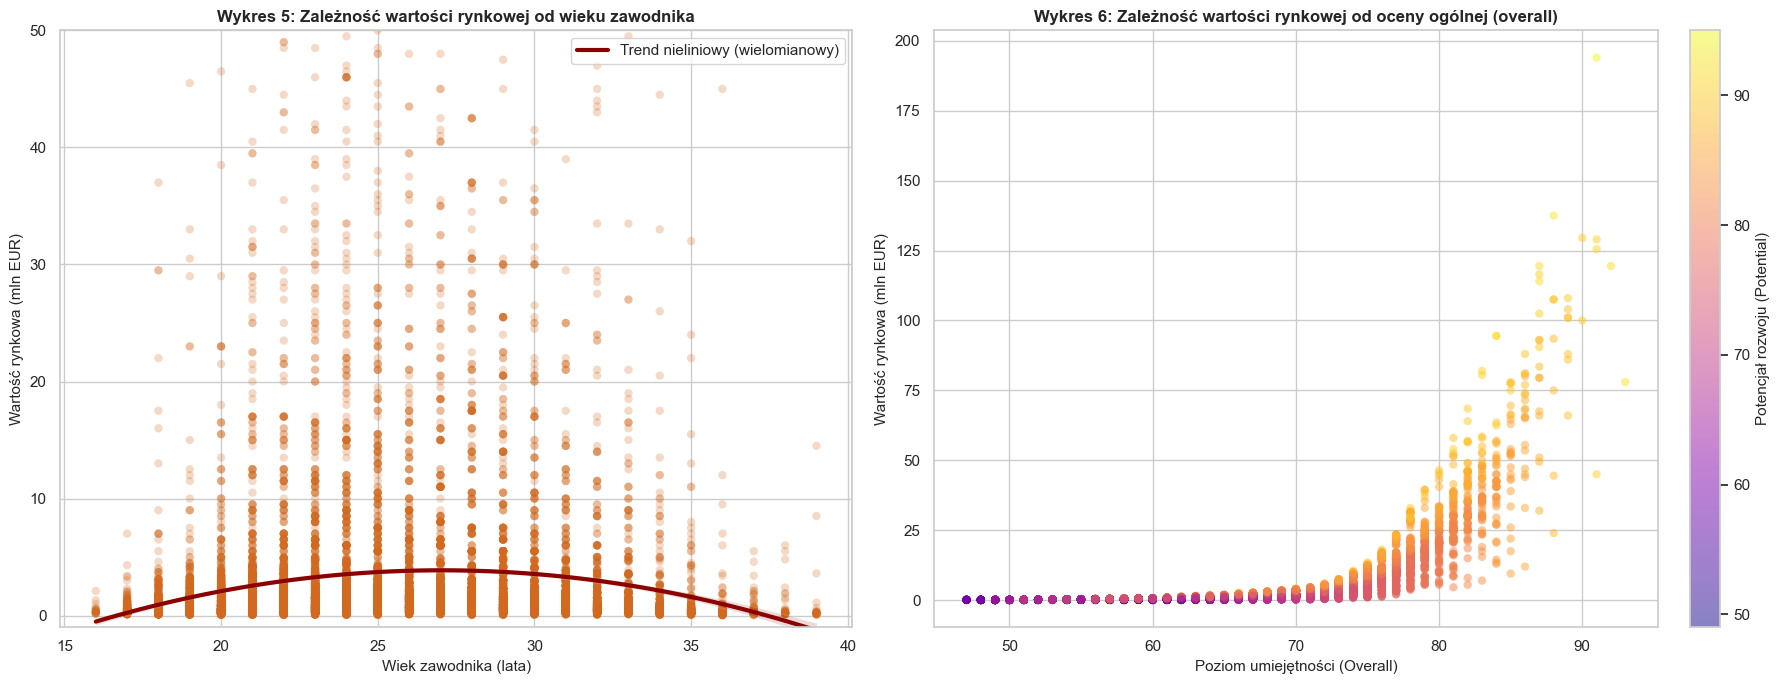

In [217]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.regplot(data=df_field, x='age', y=df_field['value_eur'] / 1_000_000, 
            order=2, ax=axes[0], color='chocolate', 
            scatter_kws={'alpha': 0.25, 'edgecolors': 'none'}, 
            line_kws={'color': 'darkred', 'lw': 3, 'label': 'Trend nieliniowy (wielomianowy)'})

axes[0].set_ylim(-1, 50) 

axes[0].set_title('Wykres 5: Zależność wartości rynkowej od wieku zawodnika', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Wiek zawodnika (lata)', fontsize=11)
axes[0].set_ylabel('Wartość rynkowa (mln EUR)', fontsize=11)
axes[0].legend(loc='upper right')


scatter = axes[1].scatter(df_field['overall'], df_field['value_eur'] / 1_000_000, 
                          c=df_field['potential'], cmap='plasma', alpha=0.5, edgecolors='none')

axes[1].set_title('Wykres 6: Zależność wartości rynkowej od oceny ogólnej (overall)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Poziom umiejętności (Overall)', fontsize=11)
axes[1].set_ylabel('Wartość rynkowa (mln EUR)', fontsize=11)

cbar = fig.colorbar(scatter, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Potencjał rozwoju (Potential)', fontsize=11)

plt.tight_layout()
plt.show()

### Zależności wartości względem wieku oraz umiejętności
Na wykresie zależności wartości od wieku zawodnika widzimy wspomnianą wyżej nieliniowość tej zależności. Piłkarze najczęściej osiągają najwyższą wycenę w wieku około 27 lat, gdy ich umiejętności znajdują się na najwyższym poziomie. Gracze starsi są już niżej wyceniani, ponieważ ich wiek wskazuje na to, że do końca kariery zostało im niedużo czasu. Natomiast młodsi piłkarze średnio są tańsi niż ich starsi koledzy ze względu na swoje niższe umiejętności.



Z Wykresu nr. 6 jasno wynika, że im większy overall piłkarza, tym wyższa jest jego wartość, jednak wysokość potencjału również ma ogromny wpływ na wycenę. Zawodnicy o wysokim potencjale są znacznie drożsi niż ich koledzy o takim samym poziomie bieżących umiejętności, lecz niższej perspektywiczności. Co ciekawe, najdrożsi piłkarze wcale nie muszą cechować się absolutnie najwyższym overallem, ale niemal zawsze wyróżniają się bardzo wysoką oceną potencjału.

In [218]:
import plotly.express as px

pozycje_boczne = ['LW', 'RW', 'LM', 'RM']
df_boczni = df_field[df_field['player_positions'].isin(pozycje_boczne)].copy()

df_boczni['value_mln'] = df_boczni['value_eur'] / 1_000_000

fig1 = px.box(
    df_boczni, 
    x='player_positions', 
    y='value_mln', 
    color='preferred_foot',
    category_orders={'player_positions': pozycje_boczne},
    title='Wykres 7: Rozkład wartości rynkowej bocznych pozycji w zależności od preferowanej nogi',
    labels={
        'player_positions': 'Pozycja zawodnika',
        'value_mln': 'Wartość rynkowa (mln EUR)',
        'preferred_foot': 'Preferowana noga'
    },
    color_discrete_map={ 'right': '#00e676','left': '#b388ff'} 
)

fig1.update_layout(
    boxmode='group', 
    title_font_size=16,
    title_font_family="Arial",
    template='plotly_white'
)

fig1.update_yaxes(range=[-0.5, 20])

fig1.show()

### Analiza rozkładu wartości bocznych pomocników
Z analizy rozkładu wartości rynkowej bocznych pozycji ofensywnych w zależności od preferowanej nogi jasno wynika, że zawodnicy występujący na skrzydle przeciwnym do ich wiodącej nogi są wyceniani znacznie wyżej. Zjawisko to jest uwarunkowane współczesnymi założeniami taktycznymi – gracz grający na flance z lepszą nogą skierowaną do wewnątrz boiska posiada znacznie większy wachlarz możliwości. Taki profil zawodnika pozwala na dynamiczne zejście z piłką do środka pola, co otwiera bezpośrednie możliwości oddania strzału na bramkę lub wykonania kluczowego podania. 

Najbardziej wyrazistym wnioskiem płynącym z wizualizacji jest fakt, że lewonożni prawoskrzydłowi charakteryzują się najwyższym sufitem finansowym oraz zdecydowanie najwyższą wartością mediany i kwartyli spośród wszystkich omawianych przypadków. Potwierdza to rynkowy deficyt klasowych, lewonożnych zawodników zdolnych do gry w sektorze prawego skrzydła, co bezpośrednio przekłada się na ich drastycznie wyższą wycenę w algorytmach bazy danych.

In [219]:
top_5_leagues = [
    'English Premier League', 
    'Spain Primera Division', 
    'German 1. Bundesliga', 
    'Italian Serie A', 
    'French Ligue 1'
]
df_rel = df_field[
    (df_field['league_name'].isin(top_5_leagues)) & 
    (df_field['overall'] > 70) &
    (df_field['value_eur'] > 0)
].copy()

def map_position_to_block(pos_string):
    if pd.isna(pos_string):
        return None
    main_pos = pos_string.split(',')[0].strip().upper()
    
    defenders = ['CB', 'LB', 'RB', 'LWB', 'RWB']
    midfielders = ['CM', 'CDM', 'CAM', 'LM', 'RM']
    
    if main_pos in defenders:
        return 'Obrońcy'
    elif main_pos in midfielders:
        return 'Pomocnicy'
    return None 
df_rel['formacja'] = df_rel['player_positions'].apply(map_position_to_block)

df_rel = df_rel[df_rel['formacja'].notna() & df_rel['wage_eur'].notna()].copy()

df_rel['wage_to_value_pct'] = (df_rel['wage_eur'] / df_rel['value_eur']) * 100

df_grouped_rel = df_rel.groupby(['league_name', 'formacja'])['wage_to_value_pct'].median().reset_index()

fig2 = px.bar(
    df_grouped_rel,
    x='league_name',
    y='wage_to_value_pct',
    color='formacja',
    barmode='group',
    title='Wykres 8: Mediana stosunku tygodniowych zarobków do wartości rynkowej zawodników (Overall > 70)',
    labels={
        'league_name': 'Liga europejska',
        'wage_to_value_pct': 'Tygodniówka jako % wartości rynkowej',
        'formacja': 'Formacja'
    },
    color_discrete_map={
        'Obrońcy': '#2979ff',
        'Pomocnicy': '#ff9100'
    },
    text_auto='.3f' 
)

fig2.update_layout(
    title_font_size=16,
    title_font_family="Arial",
    template='plotly_white',
    xaxis={'categoryorder': 'total descending'}, 
    yaxis=dict(ticksuffix=" %"),                  
    legend=dict(
        title_text="Formacja:",
        yanchor="top",
        y=0.95,
        xanchor="right",
        x=0.95
    )
)
fig2.show()

### Analiza tygodniowych zarobków piłkarzy z top 5 lig
Z analizy Wykresu 8 wynika jednoznaczny i niezwykle interesujący wniosek: we wszystkich badanych ligach TOP 5 to obrońcy charakteryzują się wyższym stosunkiem tygodniowych zarobków do swojej wartości rynkowej niż pomocnicy. Choć to zawodnicy formacji pomocy często osiągają wyższe wyceny transferowe i nominalne pensje, to w relacji kosztu płacy do realnej wartości rynkowej, defensorzy okazują się dla klubów relatywnie drożsi. Może to wynikać z faktu, że kontrakty obrońców są bardziej stabilne, a ich wycena transferowa na rynku rzadziej podlega spekulacjom giełdowym niż w przypadku graczy kreatywnych.

Równie interesującą anomalią jest pozycja hiszpańskiej Spain Primera Division, która uplasowała się na ostatnim miejscu tego zestawienia z najniższymi wskaźnikami (0.338% dla obrońców i 0.295% dla pomocników). Pomimo powszechnego uznawania ligi hiszpańskiej za drugą najlepszą ligę w Europie, tamtejsze kluby wykazują się najwyższą efektywnością kapitałową. Oznacza to, że w Hiszpanii relacja płac do rynkowej wartości zawodników jest najbardziej zbalansowana, co może być m.in. efektem restrykcyjnych limitów płacowych narzucanych przez tamtejsze władze ligowe.

### Testy statystyczne 
W celu weryfikacji postawionych przypuszczeń badawczych oraz formalnego potwierdzenia zależności zaobserwowanych na wcześniejszych wykresach, przeprowadzono wnioskowanie statystyczne. We wszystkich testach przyjęto standardowy poziom istotności $\alpha = 0,05$. Sformułowano następujące procedury weryfikacyjne:

1. **Test 1: Test normalności Shapiro-Wilka**
   * **Cel:** Zbadanie kształtu rozkładu zmiennej wartości rynkowej.
   * **$H_0$:** Rozkład wartości rynkowej piłkarzy jest normalny.
   * **$H_1$:** Rozkład wartości rynkowej piłkarzy nie jest normalny.

2. **Test 2: Parametryczny test t-Studenta dla prób niezależnych**
   * **Cel:** Porównanie średniej ceny zawodników w zależności od pozycji na boku obrony.
   * **$H_0$:** Średnia wartość rynkowa lewych obrońców ($LB$) i prawych obrońców ($RB$) jest taka sama.
   * **$H_1$:** Średnia wartość rynkowa lewych obrońców i prawych obrońców różni się w sposób istotny statystycznie.

3. **Test 3: Nieparametryczny test Manna-Whitney'a**
   * **Cel:** Porównanie rozkładu umiejętności ogólnych dla skrajnych pozycji na boisku (Napastnicy vs Środkowi Obrońcy).
   * **$H_0$:** Rozkłady umiejętności ogólnych dla pozycji $ST$ oraz $CB$ są identyczne .
   * **$H_1$:** Rozkłady umiejętności ogólnych dla pozycji $ST$ oraz $CB$ różnią się od siebie w sposób istotny statystycznie.

In [ ]:
import scipy.stats as stats

print("1. TEST NORMALNOŚCI SHAPIRO-WILKA")
stat_shapiro, p_shapiro = stats.shapiro(df_field['value_eur'].dropna())
print(f"Statystyka testowa: {stat_shapiro:.4f}")
print(f"Wartość p-value: {p_shapiro}")

print("")

print("2. TEST T-STUDENTA (ŚREDNIA CENA: LEWI VS PRAWI OBROŃCY)")
ceny_lb = df_field[df_field['player_positions'] == 'LB']['value_eur'].dropna()
ceny_rb = df_field[df_field['player_positions'] == 'RB']['value_eur'].dropna()

stat_t, p_t = stats.ttest_ind(ceny_lb, ceny_rb, equal_var=False)
print(f"Statystyka t: {stat_t:.4f}")
print(f"Wartość p-value: {p_t}")
print(f"Średnia wartość (Lewi Obrońcy - LB): {ceny_lb.mean()/1e6:.2f} mln EUR")
print(f"Średnia wartość (Prawi Obrońcy - RB): {ceny_rb.mean()/1e6:.2f} mln EUR")
print("")

print("3. TEST MANNA-WHITNEY'A (ROZKŁAD SKILLA OVERALL: NAPASTNICY VS OBROŃCY)")
overall_st = df_field[df_field['player_positions'] == 'ST']['overall'].dropna()
overall_cb = df_field[df_field['player_positions'] == 'CB']['overall'].dropna()
stat_mw, p_mw = stats.mannwhitneyu(overall_st, overall_cb, alternative='two-sided')
print(f"Statystyka U: {stat_mw:.4f}")
print(f"Wartość p-value: {p_mw}")
print(f"Mediana poziomu umiejętności (ST): {overall_st.median():.1f} pkt")
print(f"Mediana poziomu umiejętności (CB): {overall_cb.median():.1f} pkt")

1. TEST NORMALNOŚCI SHAPIRO-WILKA
Statystyka testowa: 0.3257
Wartość p-value: 5.917992922312088e-120

2. TEST T-STUDENTA (ŚREDNIA CENA: LEWI VS PRAWI OBROŃCY)
Statystyka t: -0.1106
Wartość p-value: 0.911992108083836
Średnia wartość (Lewi Obrońcy - LB): 2.44 mln EUR
Średnia wartość (Prawi Obrońcy - RB): 2.48 mln EUR

3. TEST MANNA-WHITNEY'A (ROZKŁAD SKILLA OVERALL: NAPASTNICY VS OBROŃCY)
Statystyka U: 2034386.0000
Wartość p-value: 0.02515767953354826
Mediana poziomu umiejętności (ST): 65.0 pkt
Mediana poziomu umiejętności (CB): 66.0 pkt


c:\Users\Użytkownik\Desktop\projekt python\srodowisko\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 17041.
  res = hypotest_fun_out(*samples, **kwds)


#### 1. Wyniki testu normalności Shapiro-Wilka dla wartości rynkowej
Z przeprowadzonego testu normalności Shapiro-Wilka uzyskano wartość p-value równą 5.91e-120, co przy przyjętym poziomie istotności alpha = 0.05 pozwala jednoznacznie odrzucić hipotezę zerową o normalności rozkładu zmiennej value_eur na rzecz hipotezy alternatywnej. Wynik ten jednoznacznie potwierdza silną asymetrię rozkładu wartości rynkowej zawodników. W praktyce oznacza to, że zdecydowana większość piłkarzy charakteryzuje się relatywnie niską wyceną, podczas gdy wąska grupa zawodników o statusie międzynarodowych gwiazd osiąga skrajnie wysokie wartości rynkowe.

#### 2. Wyniki testu t-Studenta dla cen lewych i prawych obrońców
W ramach drugiego kroku badawczego zastosowano parametryczny test t-Studenta dla prób niezależnych w celu zweryfikowania, czy pozycja na boku obrony różnicuje średnią wartość rynkową zawodników. Średnia wycena lewych obrońców (LB) wyniosła 2.44 mln EUR, natomiast prawych obrońców (RB) 2.48 mln EUR. Uzyskana wartość p-value na poziomie 0.9119 znacząco przewyższa przyjęty próg istotności 0.05, co oznacza brak podstaw do odrzucenia hipotezy zerowej. Różnica między średnimi dla obu pozycji wynosi zaledwie 40 tysięcy euro i jest statystycznie całkowicie nieistotna. Pozwala to na wyciągnięcie wniosku, że strona boiska w formacji obronnej nie wpływa na wycenę rynkową zawodników, a zaobserwowane odchylenie ma charakter wyłącznie losowy.

#### 3. Wyniki testu Manna-Whitney'a dla poziomu umiejętności napastników i obrońców
Ostatni etap analizy obejmował zastosowanie nieparametrycznego testu Manna-Whitney'a do porównania rozkładów poziomu umiejętności ogólnych dla napastników oraz środkowych obrońców. Wyznaczona wartość p-value wyniosła 0.0251, co przy progu alpha = 0.05 nakazuje odrzucić hipotezę zerową mówiącą o identyczności porównywanych rozkładów. Między analizowanymi pozycjami występuje istotna statystycznie różnica w poziomie umiejętności. Wartości median wskazują, że środkowi obrońcy charakteryzują się minimalnie wyższym środkiem rozkładu (mediana 66.0 pkt) w stosunku do napastników (mediana 65.0 pkt), a zaobserwowana rozbieżność nie jest dziełem przypadku, tylko stałą cechą struktury danych w badanej bazie.

In [221]:
df_cleaned = df_field.copy()

if 'club_contract_valid_until' in df_cleaned.columns:
    df_cleaned['club_contract_valid_until'] = df_cleaned['club_contract_valid_until'].fillna(0)

num_cols_initial = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
df_cleaned[num_cols_initial] = df_cleaned[num_cols_initial].fillna(df_cleaned[num_cols_initial].median())

columns_to_remove = [
    'player_url', 'face_url', 'club_logo_url', 'club_flag_url', 
    'nation_logo_url', 'nation_flag_url', 'club_loaned_from', 
    'nation_team_id', 'nation_position', 'nation_jersey_number',
    
    'short_name', 'club_name', 'nationality_name', 'league_name',
    'club_position', 'club_jersey_number', 'body_type'
]

df_cleaned = df_cleaned.drop(columns=columns_to_remove, errors='ignore')

df_cleaned['main_position'] = df_cleaned['player_positions'].apply(
    lambda x: x.split(',')[0].strip().upper() if pd.notna(x) else None
)

df_cleaned = df_cleaned.drop(columns=['player_positions'], errors='ignore')

categorical_cols = df_cleaned.select_dtypes(include=['object', 'string']).columns.tolist()

df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, dtype=int)

print(f"Liczba kolumn po wykonaniu One-Hot Encoding: {df_encoded.shape[1]}")


from sklearn.preprocessing import StandardScaler

df_scaled = df_encoded.copy()

num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()

columns_to_skip = ['league_level', 'club_contract_valid_until', 'club_jersey_number']
for col in columns_to_skip:
    if col in num_cols:
        num_cols.remove(col)

scaler = StandardScaler()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

print(f"Liczba przeskalowanych kolumn: {len(num_cols)}")

df_final = df_scaled.copy()

outlier_cols = ['value_eur', 'wage_eur']

for col in outlier_cols:
    upper_limit = df_final[col].quantile(0.99)
    count_outliers = (df_final[col] > upper_limit).sum()
    df_final[col] = df_final[col].clip(upper=upper_limit)
    print(f"Zmienna '{col}': przycięto {count_outliers} skrajnych rekordów do poziomu progu: {upper_limit.round(3)}")



def oblicz_uniwersalnosc(pozycje_string):
    if pd.isna(pozycje_string):
        return 1
    lista_pozycji = pozycje_string.split(',')
    return len(lista_pozycji)

df_final['liczba_pozycji'] = df_field['player_positions'].apply(oblicz_uniwersalnosc)

scaler_uni = StandardScaler()
df_final[['liczba_pozycji']] = scaler_uni.fit_transform(df_final[['liczba_pozycji']])

print("Funkcja 'oblicz_uniwersalnosc' została pomyślnie zaaplikowana.")
print(f"Kształt ostatecznej tabeli: {df_final.shape}")

Liczba kolumn po wykonaniu One-Hot Encoding: 75
Liczba przeskalowanych kolumn: 46
Zmienna 'value_eur': przycięto 170 skrajnych rekordów do poziomu progu: 4.41
Zmienna 'wage_eur': przycięto 157 skrajnych rekordów do poziomu progu: 4.308
Funkcja 'oblicz_uniwersalnosc' została pomyślnie zaaplikowana.
Kształt ostatecznej tabeli: (17041, 76)


In [222]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y = df_final['value_eur']
X = df_final.drop(columns=['value_eur', 'wage_eur'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Liczba próbek w zbiorze uczącym: {X_train.shape[0]} (80%)")
print(f"Liczba próbek w zbiorze testowym: {X_test.shape[0]} (20%)")

Liczba próbek w zbiorze uczącym: 13632 (80%)
Liczba próbek w zbiorze testowym: 3409 (20%)


In [223]:
results = {}
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

results['Regresja Liniowa'] = {
    'MAE': mean_absolute_error(y_test, lr_pred),
    'MSE': mean_squared_error(y_test, lr_pred),
    'R2': r2_score(y_test, lr_pred)
}

dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

results['Drzewo Decyzyjne'] = {
    'MAE': mean_absolute_error(y_test, dt_pred),
    'MSE': mean_squared_error(y_test, dt_pred),
    'R2': r2_score(y_test, dt_pred)
}

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

results['Las Losowy'] = {
    'MAE': mean_absolute_error(y_test, rf_pred),
    'MSE': mean_squared_error(y_test, rf_pred),
    'R2': r2_score(y_test, rf_pred)
}

for model_name, metrics in results.items():
    mae_val = round(metrics['MAE'], 4)
    r2_val = round(metrics['R2'], 4)

gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

results['Gradient Boosting'] = {
    'MAE': mean_absolute_error(y_test, gb_pred),
    'MSE': mean_squared_error(y_test, gb_pred),
    'R2': r2_score(y_test, gb_pred)
}

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

results['Regresja Ridge'] = {
    'MAE': mean_absolute_error(y_test, ridge_pred),
    'MSE': mean_squared_error(y_test, ridge_pred),
    'R2': r2_score(y_test, ridge_pred)
}

df_results = pd.DataFrame(results).T

df_results = df_results.sort_values(by='R2', ascending=False)

display(df_results.round(4))

,MAE,MSE,R2
Gradient Boosting,0.0194,0.0029,0.9946
Las Losowy,0.0175,0.0043,0.9920
Drzewo Decyzyjne,0.0262,0.0127,0.9764
Regresja Ridge,0.1331,0.0847,0.8425
Regresja Liniowa,0.1332,0.0847,0.8424


### Raport i interpretacja wyników modeli predykcyjnych

W ramach etapu modelowania przetestowano pięć zróżnicowanych algorytmów uczenia maszynowego (zarówno liniowych, jak i nieliniowych) w zadaniu regresji wartości rynkowej piłkarzy. Jakość prognoz każdego z modeli została oceniona za pomocą trzech standardowych metryk: MAE (średni błąd bezwzględny), MSE (błąd średniokwadratowy) oraz współczynnika determinacji $R^2$.

1. **Dominacja modeli nieliniowych :**
   Najwyższą sprawnością predykcyjną wykazał się algorytm **Gradient Boosting**, osiągając współczynnik determinacji $R^2 = 0.9946$, co oznacza, że model ten wyjaśnia aż **99.46%** całkowitej zmienności wartości rynkowej zawodników w zbiorze testowym. Tuż za nim uplasował się **Las Losowy** ($R^2 = 0.9920$). Tak wysokie wyniki dowodzą, że relacje między atrybutami piłkarza, a jego ceną mają charakter wysoce nieliniowy i sekwencyjny, co algorytmy oparte na strukturach drzewiastych potrafią bezbłędnie wychwycić.

2. **Analiza średniego błędu (MAE vs MSE):**
   Mimo że Gradient Boosting wygrał pod kątem ogólnego dopasowania ($R^2$), to **Las Losowy uzyskał najniższy średni błąd bezwzględny (MAE = 0.0175)**. Oznacza to, że w ujęciu przeciętnym Las Losowy myli się najmniej przy pojedynczych wycenach "standardowych" piłkarzy. Wyższe MSE dla Lasu Losowego przy jednoczesnym niższym MAE sugeruje jednak, że zaliczył on kilka większych, skrajnych pomyłek na najdroższych zawodnikach, które model Gradient Boosting zdołał lepiej skorygować dzięki mechanizmowi sekwencyjnego uczenia się na błędach poprzedników.

3. **Słabość podejścia liniowego:**
   Klasyczna **Regresja Liniowa** oraz **Regresja Ridge** zamknęły stawkę z niemal identycznym wynikiem. Wynik na poziomie 84% w ujęciu statystycznym jest rezultatem poprawnym, jednak wyraźnie odstaje od czołówki. Potwierdza to, że prosta kombinacja liniowa cech nie jest w stanie idealnie odwzorować dynamicznego rynku transferowego, gdzie np. przyrost umiejętności o kilka punktów u topowego zawodnika generuje wykładniczy, a nie liniowy skok jego wartości.

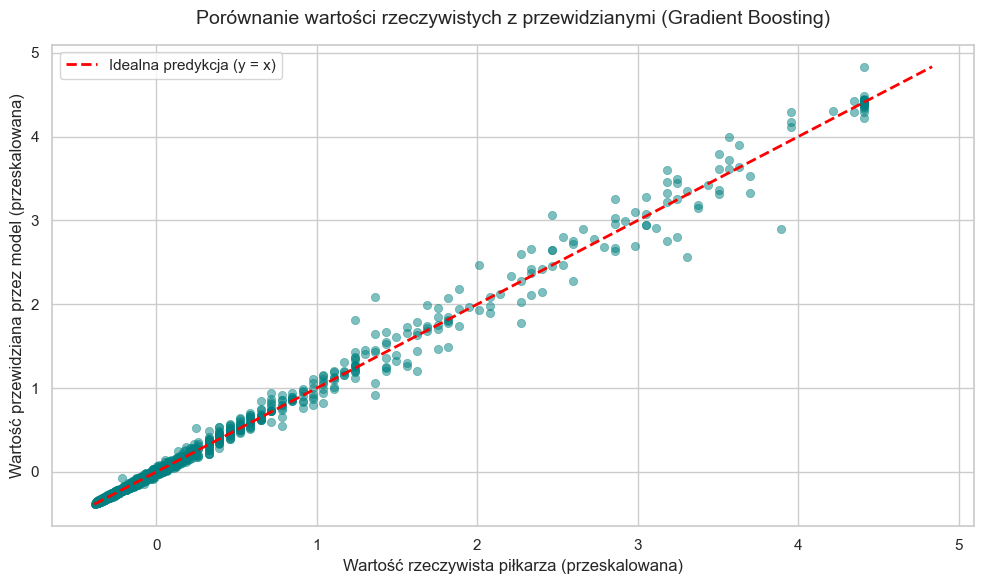

In [224]:

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(x=y_test, y=gb_pred, alpha=0.5, color='teal', edgecolor=None)

max_val = max(max(y_test), max(gb_pred))
min_val = min(min(y_test), min(gb_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Idealna predykcja (y = x)')

plt.title('Porównanie wartości rzeczywistych z przewidzianymi (Gradient Boosting)', fontsize=14, pad=15)
plt.xlabel('Wartość rzeczywista piłkarza (przeskalowana)', fontsize=12)
plt.ylabel('Wartość przewidziana przez model (przeskalowana)', fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Wizualizacja jakości predykcji

Wykres rozrzutu przedstawia bezpośrednie porównanie wartości rzeczywistych zawodników ze zbioru testowego z wartościami prognozowanymi przez najlepszy algorytm (Gradient Boosting). Czerwona, przerywana linia diagonalna ($y = x$) wyznacza poziom predykcji idealnej (miejsca, w których prognoza pokrywa się z rzeczywistością w 100%).

#### Interpretacja wykresu:

1. **Wysoki stopień dopasowania:**
   Punkty reprezentujące poszczególnych piłkarzy układają się w bardzo wąski, wyraźny pas ściśle oblepiający linię diagonalną. Świadczy to o znakomitej jakości modelu i potwierdza bardzo wysoki współczynnik determinacji ($R^2 = 0.9946$). Algorytm nie wykazuje tendencji do systematycznego niedoszacowywania lub przeszacowywania wartości rynkowej graczy w głównym spektrum danych.

2. **Zachowanie modelu w zależności od wartości piłkarza:**
   * **Dla wartości niskich i średnich:** Koncentracja punktów jest niemal idealna. W tym segmencie (reprezentującym większość bazy danych) model charakteryzuje się marginalnym błędem i potężną powtarzalnością.
   * **Dla wartości wysokich:** Wraz ze wzrostem wyceny zawodników można zauważyć delikatne rozproszenie punktów. Jest to zjawisko naturalne i w pełni uzasadnione ekonomicznie – wycena topowych gwiazd futbolu o skrajnie wysokich umiejętnościach zawsze cechuje się większą zmiennością i mniejszą przewidywalnością ze względu na unikalne czynniki rynkowe.

   METRYKI JAKOŚCI DLA MODELU GRADIENT BOOSTING
 RMSE (Root Mean Squared Error): 0.0538
   -> Pierwiastek błędu średniokwadratowego (interpretowalny bezpośrednio).

 MAPE (Mean Absolute Percentage Error): 12.3%
   -> Średni procentowy błąd bezwzględny prognoz rynkowych.


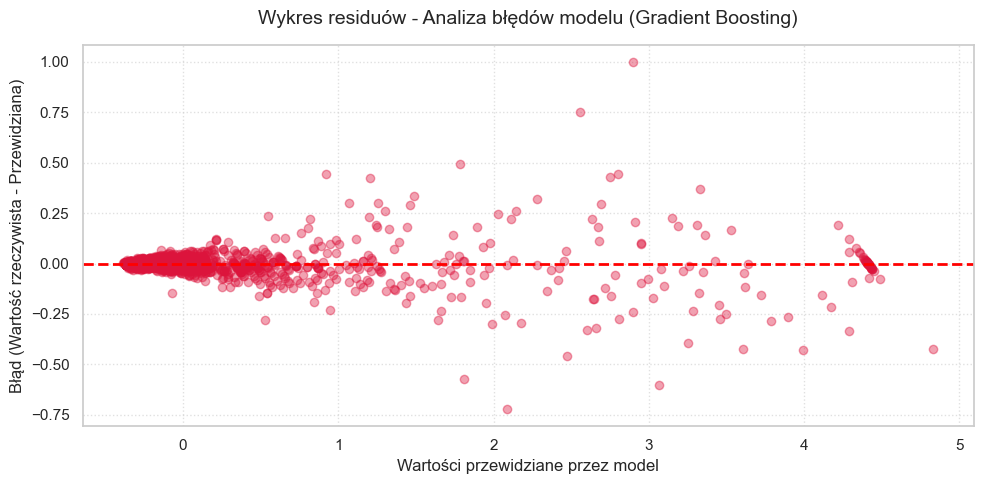

In [225]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, gb_pred)

mape = np.mean(np.abs((y_test - gb_pred) / (y_test + 1e-8))) * 100

residuals = y_test - gb_pred

print("   METRYKI JAKOŚCI DLA MODELU GRADIENT BOOSTING")
print(f" RMSE (Root Mean Squared Error): {round(rmse, 4)}")
print("   -> Pierwiastek błędu średniokwadratowego (interpretowalny bezpośrednio).")
print(f"\n MAPE (Mean Absolute Percentage Error): {round(mape, 2)}%")
print("   -> Średni procentowy błąd bezwzględny prognoz rynkowych.")

plt.figure(figsize=(10, 5))
plt.axhline(y=0, color='red', linestyle='--', linewidth=2) # Linia zero (brak błędu)

plt.scatter(gb_pred, residuals, alpha=0.4, color='crimson', edgecolor=None)

plt.title('Wykres residuów - Analiza błędów modelu (Gradient Boosting)', fontsize=14, pad=15)
plt.xlabel('Wartości przewidziane przez model', fontsize=12)
plt.ylabel('Błąd (Wartość rzeczywista - Przewidziana)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Zaawansowana ewaluacja

W celu głębszej weryfikacji stabilności modelu Gradient Boosting, analizę rozszerzono o dwa dodatkowe wskaźniki jakości oraz wykres błędów predykcji . Wykres ten obrazuje różnicę między wartością rzeczywistą a prognozowaną dla każdej obserwacji (oś Y) w odniesieniu do wartości przewidywanej przez model (oś X). Redukcję błędu idealnego wyznacza przerywana linia pozioma.

#### 1. Analiza wykresu residuów (błędów modelu):
Wykres wykazuje pożądane cechy stabilnego modelu regresyjnego. Punkty błędów są w większości rozmieszczone losowo i symetrycznie wokół linii zero. Świadczy to o tym, że model dobrze wychwycił strukturę danych i nie posiada tzw. błędu systematycznego (nie zaniża ani nie zawyża celowo prognoz dla konkretnych podgrup).

Dla najniższych wartości przewidywanych błędy są ekstremalnie skupione blisko linii zero. Oznacza to, że dla przeważającej liczby zawodników o standardowych, niższych wycenach rynkowych model wykazuje niemal perfekcyjną bezbłędność.

Wraz z przesuwaniem się w prawą stronę osi X (zawodnicy drożsi, o najwyższych prognozach), rozrzut punktów wokół linii zero delikatnie się zwiększa. Pojawiają się pojedyncze odchylenia (np. punkt w okolicach wartości 3.0 wykazujący błąd rzędu +1.0). Jest to w pełni uzasadnione specyfiką danych sportowych – wycena absolutnie topowych piłkarzy jest w rzeczywistości kształtowana przez trudne do zmierzenia algorytmem czynniki marketingowe, medialne oraz spekulacje transferowe, co generuje większy margines błędu w modelach matematycznych.
#### 2. Interpretacja dodatkowych metryk:
* **RMSE (Root Mean Squared Error) = 0.0538:** Pierwiastek błędu średniokwadratowego pozwala na bezpośrednią interpretację skali pomyłek w jednostkach zmiennej zależnej. Niski wynik (0.05) potwierdza, że odchylenie standardowe błędów prognoz jest minimalne, co świadczy o wysokiej powtarzalności modelu.
* **MAPE (Mean Absolute Percentage Error) = 12.3%:** Średni procentowy błąd bezwzględny wskazuje, że model myli się średnio o **12.3%** względem rzeczywistej wartości rynkowej piłkarza. Biorąc pod uwagę ogromną dynamikę i nieliniowość rynku transferowego, wynik na tym poziomie należy uznać za bardzo wysoki stopień precyzji predykcyjnej.



### Podsumowanie

1. **Sukces predykcyjny modeli drzewiastych:**
   Badanie zakończyło się pełnym sukcesem – modele oparte na algorytmach zespołowych i strukturach drzewiastych (Gradient Boosting oraz Las Losowy) osiągnęły wybitną dokładność predykcji, przekraczającą odpowiednio **99.46%** oraz **99.20%** wyjaśnionej wariancji na zbiorze testowym. Dowodzi to, że mechanika wyceny zawodników jest w pełni mierzalna na podstawie ich sportowych i fizycznych parametrów.

2. **Nieliniowość rynku transferowego:**
   Głównym wnioskiem płynącym z eksperymentu jest fakt, że rynek transferowy ma charakter wysoce nieliniowy. Modele liniowe poradziły sobie zauważalnie gorzej niż modele drzewiaste. Potwierdza to, że prosta suma cech nie oddaje dynamiki rynku – przyrost umiejętności u zawodnika z poziomu topowego generuje wykładniczy, a nie liniowy skok jego wartości.

3. **Stabilność i interpretowalność błędów:**
   Analiza residuów oraz dodatkowe metryki wykazały, że model Gradient Boosting jest stabilny matematycznie i nie posiada błędu systematycznego. Średnia pomyłka na poziomie 12% to świetny wynik. Model wykazuje najwyższą precyzję dla graczy o standardowych wycenach, natomiast margines błędu rośnie naturalnie w segmencie "super-gwiazd", gdzie ceny w rzeczywistości determinowane są dodatkowo przez trudne do zmierzenia czynniki marketingowe i medialne.

Stworzony potok przetwarzania danych – od czyszczenia, przez autorską inżynierię cech, aż po zaawansowane modelowanie – stanowi kompletne, gotowe i stabilne narzędzie analityczne, zdolne do obiektywnej wyceny wartości rynkowej zawodników na podstawie ich sportowego profilu w grze Fifa 22.